In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List
from pydantic import BaseModel, Field
import operator


In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.6)

In [4]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay, highlighting strengths and areas for improvement.")
    score: int = Field(description="A score out of 10 evaluating the overall quality of the essay, considering factors such as content, structure, clarity, and creativity.", le=10, ge=0)

In [5]:
class IsAiGeneratedSchema(BaseModel):
    is_ai_generated: bool = Field(description="A boolean value indicating whether the essay is likely to be AI-generated or human-written, based on the analysis of writing style, coherence, and other linguistic features.")

In [6]:
structured_model = model.with_structured_output(EvaluationSchema)
check_ai_model = model.with_structured_output(IsAiGeneratedSchema)

In [7]:
essay = """
Artificial Intelligence (AI) is playing a vital role in India’s growth and development. It is transforming various sectors such as healthcare, agriculture, education, and business by improving efficiency and decision-making. In healthcare, AI helps in early disease detection and better treatment. In agriculture, it supports farmers with crop prediction and smart farming techniques.

AI is also boosting India’s economy by promoting startups and creating new job opportunities in fields like data science and machine learning. In education, it enables personalized learning and smart classrooms. The government is using AI in areas like traffic management, digital services, and smart cities to improve governance.

However, challenges like lack of skilled professionals, data privacy concerns, and job displacement need to be addressed. Overall, AI has the potential to make India a global leader in technology if used responsibly and effectively.
"""

In [8]:
prompt = f"Evaluate the language quality of the following essay and provide detailed feedback along with a score out of 10:\n\n{essay}" 

In [9]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float
    is_ai_generated: bool

In [10]:
def check_ai_generated(state: UPSCState):
    prompt = f"Determine if the following essay is likely to be AI-generated or human-written. Provide a justification for your conclusion:\n\n{state['essay']}"
    ai_detection = check_ai_model.invoke(prompt)
    return {"is_ai_generated": ai_detection.is_ai_generated}

In [11]:
def evaluate_language(state: UPSCState):
    prompt = f"Evaluate the language quality of the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}" 
    language_evaluation = structured_model.invoke(prompt)
    return {"language_feedback": language_evaluation.feedback, "individual_scores": [language_evaluation.score]}

In [12]:
def evaluate_analysis(state: UPSCState):
    prompt = f"Evaluate the depth of analysis in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}" 
    analysis_evaluation = structured_model.invoke(prompt)
    return {"analysis_feedback": analysis_evaluation.feedback, "individual_scores": [analysis_evaluation.score]}

In [13]:
def evaluate_thought(state: UPSCState):
    prompt = f"Evaluate the clarity of thought in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}" 
    thought_evaluation = structured_model.invoke(prompt)
    return {"clarity_feedback": thought_evaluation.feedback, "individual_scores": [thought_evaluation.score]}

In [14]:
def final_evaluation(state: UPSCState):
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])
    prompt = f"Based on the following feedback and scores for language, analysis, and clarity of thought, provide an overall evaluation of the essay:\n\nLanguage Feedback: {state['language_feedback']}\nAnalysis Feedback: {state['analysis_feedback']}\nClarity of Thought Feedback: {state['clarity_feedback']}"
    overall_evaluation = model.invoke(prompt)
    return {"overall_feedback": overall_evaluation.content, "avg_score": avg_score}

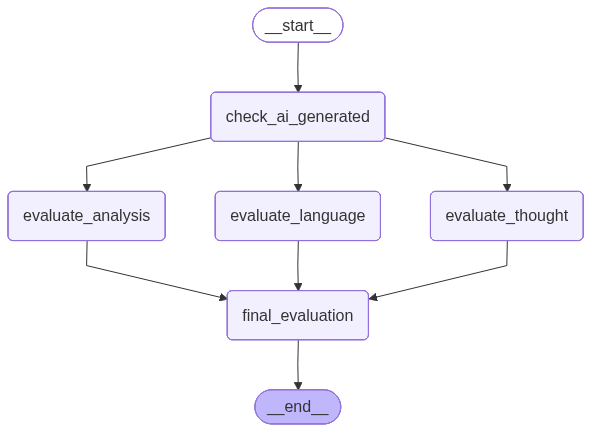

In [15]:
graph = StateGraph(UPSCState)

graph.add_node("check_ai_generated", check_ai_generated)
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node("final_evaluation",final_evaluation)

graph.add_edge(START, "check_ai_generated")
graph.add_edge("check_ai_generated", "evaluate_language")
graph.add_edge("check_ai_generated", "evaluate_analysis")
graph.add_edge("check_ai_generated", "evaluate_thought")
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")
graph.add_edge("final_evaluation", END)

workflow = graph.compile()
workflow

In [16]:
initial_state = {"essay": essay}
workflow.invoke(initial_state)

{'essay': '\nArtificial Intelligence (AI) is playing a vital role in India’s growth and development. It is transforming various sectors such as healthcare, agriculture, education, and business by improving efficiency and decision-making. In healthcare, AI helps in early disease detection and better treatment. In agriculture, it supports farmers with crop prediction and smart farming techniques.\n\nAI is also boosting India’s economy by promoting startups and creating new job opportunities in fields like data science and machine learning. In education, it enables personalized learning and smart classrooms. The government is using AI in areas like traffic management, digital services, and smart cities to improve governance.\n\nHowever, challenges like lack of skilled professionals, data privacy concerns, and job displacement need to be addressed. Overall, AI has the potential to make India a global leader in technology if used responsibly and effectively.\n',
 'language_feedback': "The e